# Task 3:  Nested Cross-Validation: Baseline & Algorithm Selection

## Libraries

In [1]:
DATA_PATH = '../data/students_dataset.csv'
###########################
#Reproducibility
import random, os, warnings
import numpy as np
import pandas as pd
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')  
###########################
#Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.1)
##########################
import sys
sys.path.insert(0, '../src')
from script import*
##########################
#Libraries for the seven defined algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


## Loading the Data

In [2]:
df_raw = pd.read_csv(DATA_PATH) 
df = df_raw.copy()
df['num'] = (df['num'] > 0).astype(int)  
X = df.drop(columns='num')
y = df['num']
print(f'Dataset shape: {X.shape}')
print(f'Class distribution:\n{y.value_counts()}')

Dataset shape: (242, 13)
Class distribution:
num
0    131
1    111
Name: count, dtype: int64


## Defining the Estimators

In [3]:
# All classifiers are initialised with default hyperparameters. Seeds are fixed where applicable.
estimators = [
    ('LR',       LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=10000, random_state=SEED)),
    ('GNB',      GaussianNB()),
    ('LDA',      LinearDiscriminantAnalysis()),
    ('RF',       RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('LightGBM', LGBMClassifier(n_estimators=100, random_state=SEED,
                                  verbose=-1, n_jobs=-1)),
    ('XGBoost',  XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss', verbosity=0, n_jobs=-1)),
    ('CatBoost', CatBoostClassifier(iterations=100, random_seed=SEED,verbose=0)),]

print('Estimators defined:', [name for name, _ in estimators])

Estimators defined: ['LR', 'GNB', 'LDA', 'RF', 'LightGBM', 'XGBoost', 'CatBoost']


## Baseline Comparison with No Tuning


In [4]:
# Disabling the inner loop & running 10 repetitions of 5-fold CV
# in order to get a fair baseline across algorithms with default hyperparameters.

baseline_rncv = RepeatedNestedCV( estimators=estimators, param_spaces={}, n_repeats=10, n_outer=5, n_inner=3,
    base_seed=SEED, tune=False,feature_selection=False,)

baseline_rncv.fit(X, y)
baseline_summary = baseline_rncv.summary()
baseline_summary[['MCC_median', 'AUC_median', 'BA_median', 'F1_median', 'Recall_median', 'Specificity_median']]

,MCC_median,AUC_median,BA_median,F1_median,Recall_median,Specificity_median
Estimator,,,,,,
LR,0.6290,0.8907,0.8129,0.8000,0.7727,0.8682
GNB,0.4477,0.8636,0.6917,0.7321,0.9091,0.4715
LDA,0.6643,0.8855,0.8287,0.8095,0.7727,0.8846
RF,0.6080,0.8842,0.7971,0.7805,0.7727,0.8462
LightGBM,0.5641,0.8628,0.7753,0.7556,0.7727,0.8077
XGBoost,0.5903,0.8654,0.7902,0.7710,0.7727,0.8077
CatBoost,0.5943,0.8885,0.7945,0.7777,0.7727,0.8462


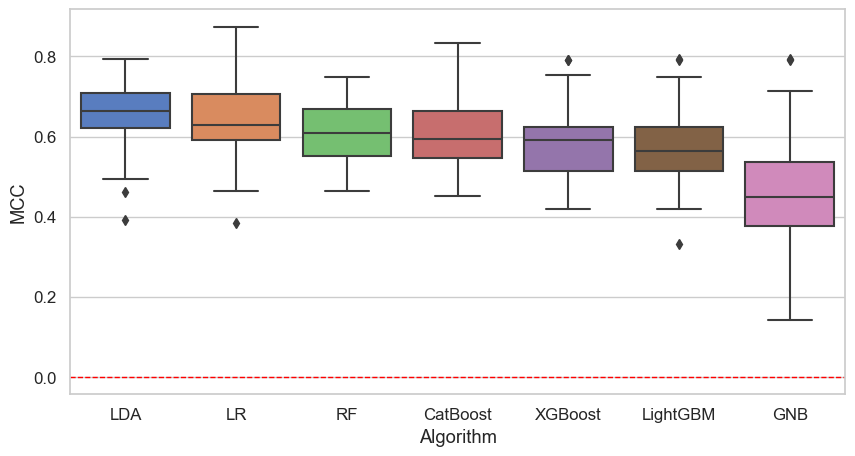

In [5]:
# Visualisazion of baseline MCC distributions across algorithms
mcc_data = []

for clf_name in baseline_rncv.results_:
    folds_df = baseline_rncv.get_fold_results(clf_name)
    for val in folds_df['MCC'].values:
        mcc_data.append({'Estimator': clf_name, 'MCC': val})
mcc_df = pd.DataFrame(mcc_data)


fig, ax = plt.subplots(figsize=(10, 5))
order = mcc_df.groupby('Estimator')['MCC'].median().sort_values(ascending=False).index
sns.boxplot(data=mcc_df, x='Estimator', y='MCC', order=order, palette='muted', ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Algorithm')



plt.suptitle('')   
plt.savefig('../figures/baseline_mcc.png', bbox_inches='tight')
plt.show()

**Comment:** Since the MCC boxplots compare the baseline performance of all algorithms across 50 outer-fold evaluations, it is indicated that the LDA and Logistic Regression show the highest median MCC values and relatively stable performance, while Gaussian Naive Bayes shows the lowest median MCC and higher variability. 

## Defining the Hyperparameter Spaces for rnCV

In [6]:
# Each space is defined as a callable accepting an Optuna `trial` object.
#Tuning regularization strength & L1/L2 mixing for ElasticNet regularization
def lr_space(trial):
    return {
        'C':        trial.suggest_float('C', 1e-3, 10.0, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
        'max_iter': 10000,
        'penalty':  'elasticnet',
        'solver':   'saga',
        'random_state': SEED,
    }

# Tuning variance smoothing to improve numerical stability and regularization.
def gnb_space(trial):
    return {
        'var_smoothing': trial.suggest_float('var_smoothing', 1e-11, 1e-6, log=True),
    }

# Tuning solver and shrinkage to regularize the covariance estimate, since we are having a small dataset.
def lda_space(trial):
    solver = trial.suggest_categorical('solver', ['lsqr', 'eigen'])
    return {
        'solver':    solver,
        'shrinkage': trial.suggest_float('shrinkage', 0.0, 1.0),
    }
# Tuning tree number, depth, leaf size, and feature sampling to control complexity and overfitting.
def rf_space(trial):
    return {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth':       trial.suggest_int('max_depth', 3, 15),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'class_weight':    'balanced',
        'random_state':    SEED,
        'n_jobs':         -1,
    }

# Tuning boosting rounds, learning rate, tree complexity, and regularization to balance bias and variance.
def lgbm_space(trial):
    return {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':       trial.suggest_int('max_depth', 3, 10),
        'num_leaves':      trial.suggest_int('num_leaves', 15, 63),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'class_weight':    'balanced',
        'random_state':    SEED,
        'verbose':        -1,
        'n_jobs':         -1,
    }

# Tuning boosting rounds, learning rate, tree depth, subsampling, and regularization to reduce overfitting.
def xgb_space(trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 8),
        'subsample':     trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':     trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda':    trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'eval_metric':   'logloss',
        'verbosity':     0,
        'random_state':  SEED,
        'n_jobs':       -1,
    }
# Tuning iterations, learning rate, tree depth, and L2 regularization to control boosting complexity.
def catboost_space(trial):
    return {
        'iterations':    trial.suggest_int('iterations', 50, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':         trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed':   SEED,
        'verbose':       0,
    }

param_spaces = {'LR': lr_space,'GNB': gnb_space,'LDA': lda_space,'RF': rf_space, 'LightGBM': lgbm_space, 
                'XGBoost':  xgb_space,'CatBoost': catboost_space,}

print('Finished defining hyperparam space.')

Finished defining hyperparam space.


---

## Running the  rnCV (R=10, N=5, K=3)

Main evaluation --> Each algorithm is assessed across **50 outer test folds** (5 folds × 10 repeats).

> This cell takes approximatelly 90-100 minutes due to my laptop's hardware and It tuns in `n_trials=50`.

In [7]:
script = RepeatedNestedCV(estimators=estimators, param_spaces=param_spaces, 
                          n_repeats=10, n_outer=5,n_inner=3,n_trials=50,
                          base_seed=SEED,tune=True, feature_selection=False,inner_metric='roc_auc',)
print(type(X))
script.fit(X, y)
print('rnCV complete.')

<class 'pandas.core.frame.DataFrame'>
rnCV complete.


---



## Algorithm Comparison

In [8]:
# Τhe comparison of the algorithms occurs by using median metrics across all 50 outer test folds,
# with 95% bootstrapped confidence intervals.
summary = script.summary(ci_level=0.95)

# Display key metrics
key_cols = ['MCC_median', 'MCC_CI_lo', 'MCC_CI_hi','AUC_median', 'BA_median', 'F1_median','Recall_median', 'Specificity_median', 'PRAUC_median']
print('rnCV Summary (median ± 95% CI)')
display(summary[key_cols].sort_values('MCC_median', ascending=False))

rnCV Summary (median ± 95% CI)


,MCC_median,MCC_CI_lo,MCC_CI_hi,AUC_median,BA_median,F1_median,Recall_median,Specificity_median,PRAUC_median
Estimator,,,,,,,,,
LDA,0.6643,0.6296,0.6751,0.8974,0.8217,0.7907,0.7727,0.8846,0.8906
LR,0.6302,0.6234,0.6700,0.8899,0.8126,0.7907,0.7727,0.8846,0.8897
RF,0.6296,0.5943,0.6643,0.8966,0.8070,0.7867,0.7727,0.8846,0.8941
XGBoost,0.6283,0.5830,0.6408,0.8829,0.8023,0.7780,0.7727,0.8682,0.8855
CatBoost,0.6234,0.5913,0.6327,0.8916,0.8059,0.7815,0.7727,0.8490,0.8883
LightGBM,0.5857,0.5513,0.6080,0.8733,0.7867,0.7619,0.7332,0.8462,0.8790
GNB,0.4419,0.4173,0.5300,0.8636,0.7010,0.7213,0.9091,0.5285,0.8558


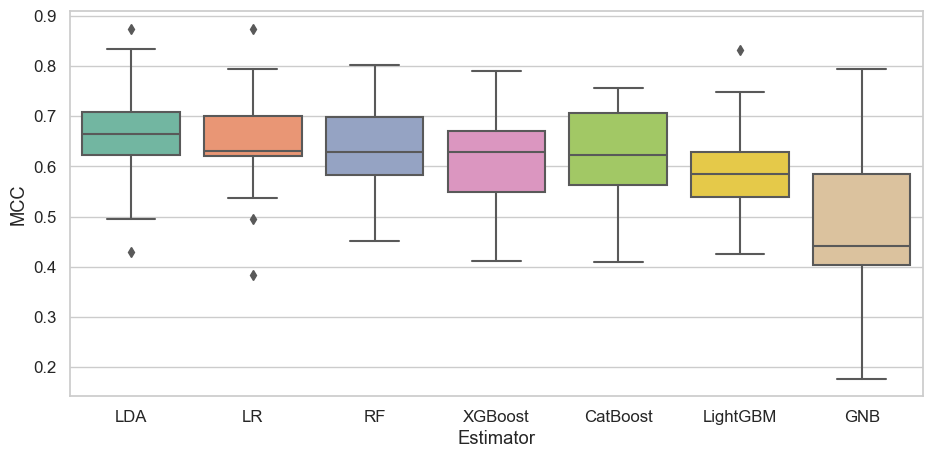

In [11]:
# Box plots showing the MCC across all outer folds per algorithm
mcc_data_tuned = []
for clf_name in script.results_:
    folds_df = script.get_fold_results(clf_name)
    for val in folds_df['MCC'].values:
        mcc_data_tuned.append({'Estimator': clf_name, 'MCC': val})
mcc_df_tuned = pd.DataFrame(mcc_data_tuned)


fig, ax = plt.subplots(figsize=(11, 5))
order = mcc_df_tuned.groupby('Estimator')['MCC'].median().sort_values(ascending=False).index
sns.boxplot(data=mcc_df_tuned, x='Estimator', y='MCC', order=order, palette='Set2', ax=ax)


plt.suptitle('') 
plt.savefig('../figures/rncv_mcc_tuned.png', bbox_inches='tight')
plt.show()

**Comment:** The MCC distributions show that `LDA` across the 50 outer-test achieved the `highest median MCC` among the tuned algorithms, followed closely by Logistic Regression, Random Forest, XGBoost, and CatBoost. 

- LDA also seems `relatively stable`, with most fold scores concentrated in a high MCC range. 
- Gaussian Naive Bayes on the contrary, showed the `lowest median MCC` and the `largest variability`, suggesting `less stable` performance across folds.

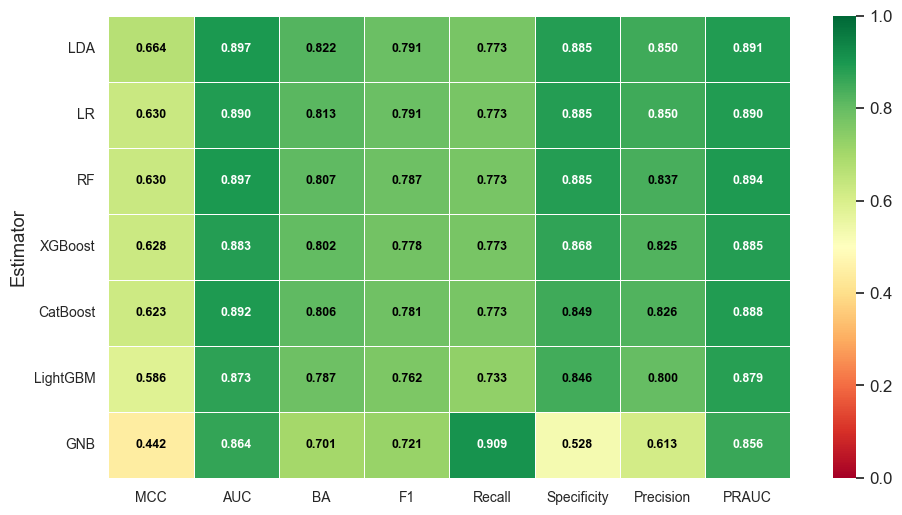

In [17]:
# Multi-metric heatmap for final comparison
metric_medians = summary[[c for c in summary.columns if '_median' in c]].copy()
metric_medians.columns = [c.replace('_median', '') for c in metric_medians.columns]
metric_medians = metric_medians.sort_values('MCC', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap( metric_medians,annot=False,cmap='RdYlGn',vmin=0, vmax=1,linewidths=0.5,ax=ax,)

# Manually placing every annotation due to bug (only first line results appearing)
for i in range(metric_medians.shape[0]):
    for j in range(metric_medians.shape[1]):
        val = metric_medians.iloc[i, j]
        text_color = 'black' if 0.25 < val < 0.85 else 'white'
        ax.text(j + 0.5, i + 0.5, f'{val:.3f}', ha='center', va='center',fontsize=9,color=text_color,fontweight='bold',)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.suptitle('') 
plt.savefig('../figures/metric_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

**Comment:** The resulting heat map shows that the LDA achieved the `highest median MCC` while also maintaining strong performance across the `remaining metrics`. 

`Second` in the row, `Logistic Regression` and `Random Forest` performed very similarly, with only slightly lower median MCC values. 
`XGBoost` and `CatBoost` also showed `competitive results`, while `LightGBM` had `lower MCC` and `balanced accuracy compared` with the top-performing models. 

Regarding, `Gaussian Naive Bayes`, it showed the `lowest MCC` and `weaker specificity and precision, despite having the highest recall` --> Indicating possibly that GNB identified many positive cases but also produced more false positives, making its performance less balanced. 

## Winner Selection


In [14]:
# Identify winner
winner_name = summary['MCC_median'].idxmax()
winner_row  = summary.loc[winner_name]

print(f'Winner: {winner_name}')
print(f'  MCC  : {winner_row["MCC_median"]:.4f} (95% CI: [{winner_row["MCC_CI_lo"]:.4f}, {winner_row["MCC_CI_hi"]:.4f}])')
print(f'  AUC  : {winner_row["AUC_median"]:.4f}')
print(f'  BA   : {winner_row["BA_median"]:.4f}')
print(f'  F1   : {winner_row["F1_median"]:.4f}')
print(f'  Recall: {winner_row["Recall_median"]:.4f}')

# Save winner name for downstream notebooks
import json
with open('../results/winner.json', 'w') as f:
    json.dump({'winner': winner_name}, f)
print('Winner saved to ../results/winner.json')

Winner: LDA
  MCC  : 0.6643 (95% CI: [0.6296, 0.6751])
  AUC  : 0.8974
  BA   : 0.8217
  F1   : 0.7907
  Recall: 0.7727
Winner saved to ../results/winner.json


In [15]:
# Save full results for reproducibility
all_results = {}
for clf_name in script.results_:
    all_results[clf_name] = script.get_fold_results(clf_name).to_dict(orient='records')

with open('../results/rncv_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('Results saved.')

Results saved.
